# Projeto Final de PCP - Planejamento Agregado da Producao

**Disciplina:** Planejamento e Controle da Producao (EPR/FT/UnB)
**Autor:** Tiago Andre Gondim - Matricula 231013476

**Tema (eixo central):** Planejamento Agregado da Producao por Programacao Linear.
**Integracoes:** Previsao de Demanda (Holt-Winters / SARIMA) + Gestao de Estoque / Nivel de Servico.

Pipeline ponta a ponta e reproduzivel: demanda -> previsao -> plano agregado -> cenarios
-> sensibilidade/incerteza -> decisao. Premissas e calibracao em `docs/00_premissas.md`.

## 0. Configuracao e reprodutibilidade

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

import config, parametros, modelo  # noqa: E402
from config import SEED, get_rng
from parametros import (demanda_esperada, demanda_simulada, serie_historica,
                        CUSTOS, CAPACIDADE, HORIZONTE_MESES,
                        NIVEL_SERVICO_ALVO, Z_NIVEL_SERVICO, DEMANDA)
from modelo import resolve_pap
import estilo
from estilo import C_REGULAR, C_EXTRA, C_ESTOQUE, C_DESTAQUE, C_REF
estilo.aplicar_estilo()

plt.rcParams['figure.figsize'] = (9, 4)
print(f'SEED = {SEED} | horizonte = {HORIZONTE_MESES} meses | '
      f'nivel de servico alvo = {NIVEL_SERVICO_ALVO:.0%}')

SEED = 42 | horizonte = 12 meses | nivel de servico alvo = 95%


## 1. Demanda do ano de planejamento

Serie sazonal de um fabricante de ventiladores: vale no mes 1 (baixa estacao) e pico
no mes 7 (verao). A serie esperada e o forecast deterministico adotado; a simulada
adiciona ruido multiplicativo Normal (CV = 8%), reproduzivel pela semente.

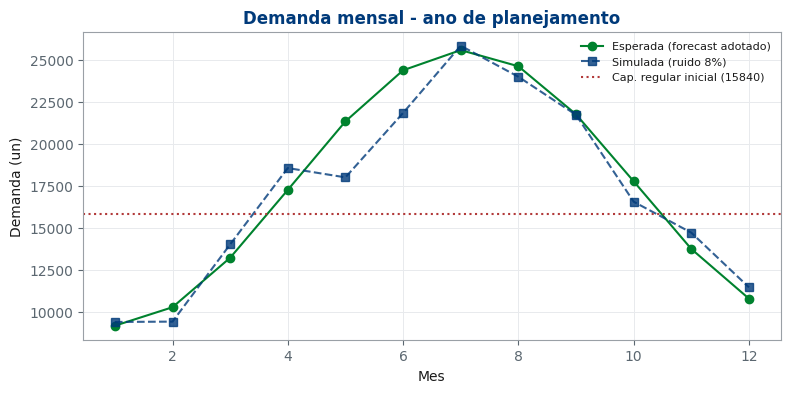

,mes,demanda_esperada,demanda_simulada
0,1,9180.0,9403.8
1,2,10278.8,9423.6
2,3,13220.9,14014.6
3,4,17255.0,18553.4
4,5,21328.2,17999.2
5,6,24366.6,21828.2
6,7,25564.6,25826.1
7,8,24604.3,23981.9
8,9,21746.4,21717.2
9,10,17765.0,16552.7


In [2]:
meses = np.arange(1, HORIZONTE_MESES + 1)
D_esp = demanda_esperada()
D_sim = demanda_simulada(get_rng())

df_dem = pd.DataFrame({'mes': meses,
                       'demanda_esperada': np.round(D_esp, 1),
                       'demanda_simulada': np.round(D_sim, 1)})
(ROOT / 'data' / 'raw').mkdir(parents=True, exist_ok=True)
df_dem.to_csv(ROOT / 'data' / 'raw' / 'demanda.csv', index=False)

cap_reg = CAPACIDADE['produtividade_por_trab_mes'] * CAPACIDADE['trabalhadores_inicial']
fig, ax = plt.subplots()
ax.plot(meses, D_esp, 'o-', label='Esperada (forecast adotado)')
ax.plot(meses, D_sim, 's--', alpha=0.8, label='Simulada (ruido 8%)')
ax.axhline(cap_reg, color=C_REF, ls=':', label=f'Cap. regular inicial ({cap_reg:.0f})')
ax.set(xlabel='Mes', ylabel='Demanda (un)', title='Demanda mensal - ano de planejamento')
ax.legend(fontsize=8)
plt.show()
df_dem

## 2. Previsao de demanda (integracao I)

Para prever o ano de planejamento e preciso HISTORICO. Geramos 5 anos de demanda
mensal consistentes com a demanda esperada e a tendencia anual (+6%/ano), ajustamos
modelos no historico, validamos em um holdout de 12 meses (1 ciclo sazonal) e
projetamos o proximo ano. O modelo escolhido reproduz o forecast adotado e fornece a
distribuicao do erro que alimentara o estoque de seguranca e o Monte Carlo (Fase 5).

Ferramental alinhado ao da disciplina: `statsmodels` (SES, Holt-Winters, SARIMA) e
`sklearn.metrics` (MAE, RMSE), acrescido de MAPE (exigido no enunciado).

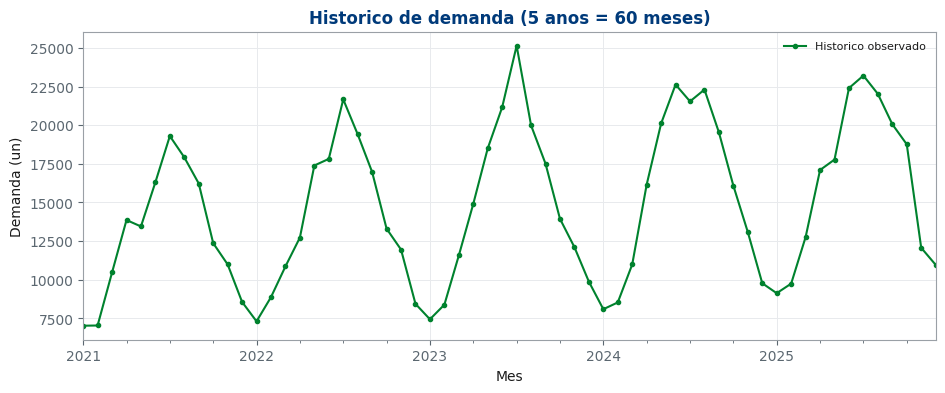

Historico: 60 meses | media=14762


In [3]:
ANOS_HIST = 5
hist = serie_historica(anos_hist=ANOS_HIST, rng=get_rng())
idx = pd.period_range('2021-01', periods=len(hist), freq='M')
serie = pd.Series(hist, index=idx, name='demanda')

fig, ax = plt.subplots(figsize=(11, 4))
serie.plot(ax=ax, marker='.', label='Historico observado')
ax.set(xlabel='Mes', ylabel='Demanda (un)',
       title=f'Historico de demanda ({ANOS_HIST} anos = {len(hist)} meses)')
ax.legend(fontsize=8)
plt.show()
print(f'Historico: {len(hist)} meses | media={serie.mean():.0f}')

### 2.1 Separacao treino / teste (holdout = ultimos 12 meses)

In [4]:
h = HORIZONTE_MESES
train, test = serie.iloc[:-h], serie.iloc[-h:]

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def metrics(y_true, y_pred):
    return {'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': root_mean_squared_error(y_true, y_pred),
            'MAPE(%)': mape(y_true, y_pred)}

print(f'Treino: {len(train)} meses | Teste (holdout): {len(test)} meses')

Treino: 48 meses | Teste (holdout): 12 meses


### 2.2 Ajuste dos modelos e previsao do holdout

Dois baselines ingenuos (media movel e SES, sem sazonalidade) e dois modelos
sazonais (Holt-Winters e SARIMA). Espera-se que os sazonais vencam com folga.

In [5]:
y_tr = train.values.astype(float)
prev = {}
prev['Media Movel(3)'] = np.repeat(pd.Series(y_tr).rolling(3).mean().iloc[-1], h)
prev['SES'] = SimpleExpSmoothing(y_tr).fit().forecast(h)
prev['Holt-Winters'] = ExponentialSmoothing(
    y_tr, trend='add', seasonal='mul', seasonal_periods=12).fit().forecast(h)
try:
    prev['SARIMA'] = np.asarray(SARIMAX(
        y_tr, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False).forecast(h))
except Exception as e:
    print('SARIMA falhou:', e)

tab_metr = pd.DataFrame({n: metrics(test.values, yh) for n, yh in prev.items()}).T
tab_metr = tab_metr.sort_values('RMSE')
tab_metr.round(1)

,MAE,RMSE,MAPE(%)
SARIMA,888.2,1310.2,5.4
Holt-Winters,1118.6,1525.8,6.4
Media Movel(3),5058.0,5977.6,28.9
SES,6671.3,8217.3,34.8


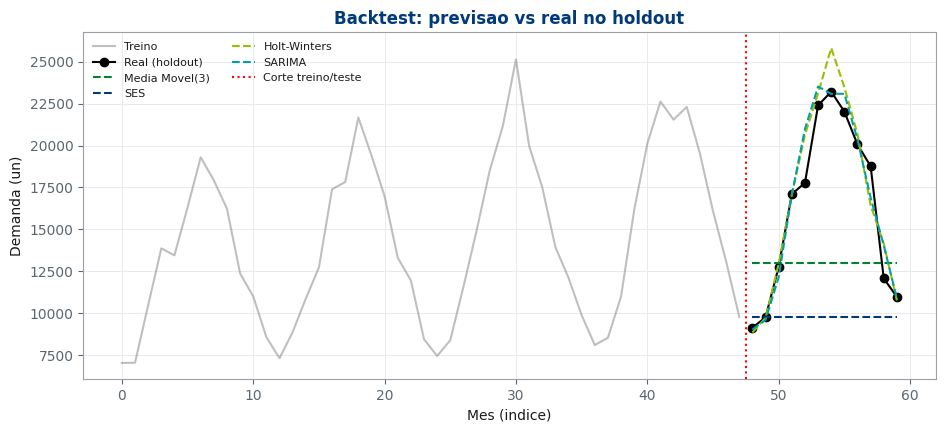

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(range(len(y_tr)), y_tr, color='gray', alpha=0.5, label='Treino')
tx = range(len(y_tr), len(y_tr) + h)
ax.plot(tx, test.values, 'k-o', label='Real (holdout)')
for nome, yhat in prev.items():
    ax.plot(tx, yhat, '--', label=nome)
ax.axvline(len(y_tr) - 0.5, color='red', ls=':', label='Corte treino/teste')
ax.set(xlabel='Mes (indice)', ylabel='Demanda (un)',
       title='Backtest: previsao vs real no holdout')
ax.legend(fontsize=8, ncol=2)
plt.show()

**Leitura:** os modelos sazonais (SARIMA e Holt-Winters) reduzem o erro cerca de
5x frente aos baselines sem sazonalidade (media movel e SES). Em demanda sazonal,
repetir o ultimo valor observado e insuficiente: e preciso capturar a estrutura de
ciclo. Escolho o modelo de menor RMSE no holdout.

### 2.3 Escolha do modelo, projecao e erro de previsao

Modelo escolhido (menor RMSE no holdout): SARIMA


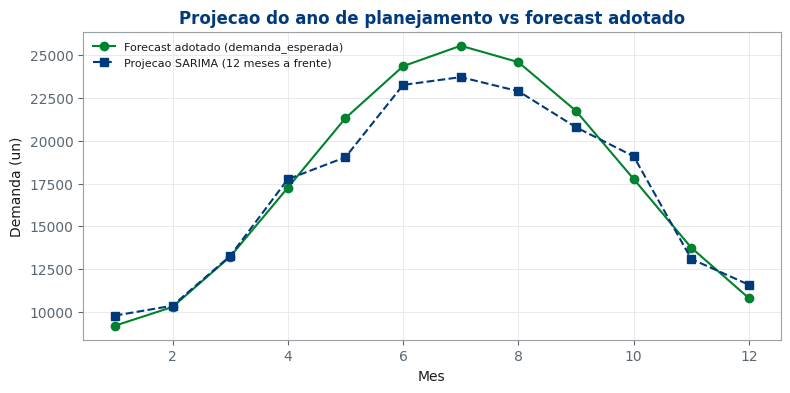

Aderencia da projecao ao forecast adotado: MAPE = 5.3%
Erro do modelo escolhido no holdout: RMSE = 1,310 un (~8.0% da demanda media)
Estoque de seguranca no pico (z=1.645, servico 95%): ~3,373 un  ->  usado nas Fases 5.3 e 5.4


In [7]:
melhor = tab_metr.index[0]
print(f'Modelo escolhido (menor RMSE no holdout): {melhor}')

y_full = serie.values.astype(float)
if melhor == 'Holt-Winters':
    fc = ExponentialSmoothing(y_full, trend='add', seasonal='mul',
                              seasonal_periods=12).fit().forecast(h)
elif melhor == 'SARIMA':
    fc = np.asarray(SARIMAX(y_full, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12),
                            enforce_stationarity=False,
                            enforce_invertibility=False).fit(disp=False).forecast(h))
elif melhor == 'SES':
    fc = SimpleExpSmoothing(y_full).fit().forecast(h)
else:
    fc = np.repeat(pd.Series(y_full).rolling(3).mean().iloc[-1], h)

fig, ax = plt.subplots()
ax.plot(meses, D_esp, 'o-', label='Forecast adotado (demanda_esperada)')
ax.plot(meses, fc, 's--', label=f'Projecao {melhor} (12 meses a frente)')
ax.set(xlabel='Mes', ylabel='Demanda (un)',
       title='Projecao do ano de planejamento vs forecast adotado')
ax.legend(fontsize=8)
plt.show()

cv_erro = tab_metr.loc[melhor, 'RMSE'] / test.mean()
sigma_pico = cv_erro * D_esp.max()
ss_pico = Z_NIVEL_SERVICO * sigma_pico
print(f'Aderencia da projecao ao forecast adotado: MAPE = {mape(D_esp, fc):.1f}%')
print(f'Erro do modelo escolhido no holdout: RMSE = {tab_metr.loc[melhor, "RMSE"]:,.0f} un '
      f'(~{cv_erro*100:.1f}% da demanda media)')
print(f'Estoque de seguranca no pico (z={Z_NIVEL_SERVICO}, servico '
      f'{NIVEL_SERVICO_ALVO:.0%}): ~{ss_pico:,.0f} un  ->  usado nas Fases 5.3 e 5.4')

## 3. Planejamento agregado da producao (plano misto)

O PL de custo-relevante (`src/modelo.py`) e resolvido sobre o forecast adotado. A
saida e uma decisao: quanto produzir (regular e hora extra), qual a forca de trabalho
(contratar/demitir) e quanto estocar em cada mes.

In [8]:
res = resolve_pap(D_esp, 'misto')
print(f'Status: {res.status} | Custo total relevante: R$ {res.custo_total:,.0f}')
plano = pd.DataFrame(res.plano, index=meses).rename(columns={
    'W': 'trabalhadores', 'P': 'prod_regular', 'O': 'hora_extra',
    'I': 'estoque', 'B': 'atraso', 'H': 'contrata', 'F': 'demite'})
plano.insert(0, 'demanda', np.round(D_esp).astype(int))
plano[['demanda', 'trabalhadores', 'prod_regular', 'hora_extra', 'estoque', 'atraso']]

Status: Optimal | Custo total relevante: R$ 4,915,334


,demanda,trabalhadores,prod_regular,hora_extra,estoque,atraso
1,9180,88.0,13999.296,0.0,6819.296,0.0
2,10279,88.0,15840.000,0.0,12380.476,0.0
3,13221,92.0,16560.000,0.0,15719.576,0.0
4,17255,96.0,17280.000,0.0,15744.576,0.0
5,21328,100.0,18000.000,0.0,12416.376,0.0
6,24367,104.0,18720.000,2246.4,9016.150,0.0
7,25565,104.0,18720.000,2246.4,4417.950,0.0
8,24604,104.0,18720.000,2246.4,780.000,0.0
9,21746,104.0,18720.000,2246.4,0.000,0.0
10,17765,100.0,17765.000,0.0,0.000,0.0


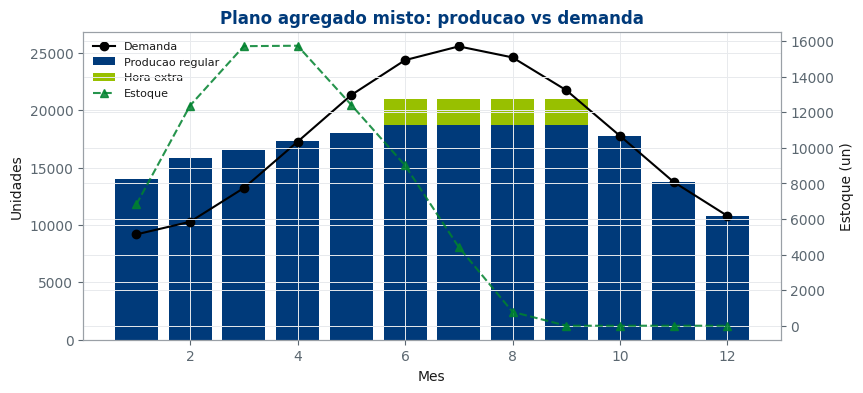

In [9]:
fig, ax1 = plt.subplots()
ax1.bar(meses, plano['prod_regular'], color=C_REGULAR, label='Producao regular')
ax1.bar(meses, plano['hora_extra'], bottom=plano['prod_regular'],
        color=C_EXTRA, label='Hora extra')
ax1.plot(meses, plano['demanda'], 'k-o', label='Demanda')
ax1.set(xlabel='Mes', ylabel='Unidades', title='Plano agregado misto: producao vs demanda')
ax2 = ax1.twinx()
ax2.plot(meses, plano['estoque'], '--^', color=C_ESTOQUE, alpha=0.85, label='Estoque')
ax2.set_ylabel('Estoque (un)')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)
plt.show()

## 4. Analise de cenarios (nivel x perseguicao x mista)

As tres estrategias sao o mesmo PL com restricoes distintas. A comparacao revela os
trade-offs: nivel evita ajustes de mao de obra mas paga estoque; perseguicao evita
estoque mas paga contratacao/demissao e atraso no pico.

In [10]:
estr = {m: resolve_pap(D_esp, m) for m in ('misto', 'nivel', 'perseguicao')}
dec = pd.DataFrame({m: r.custo for m, r in estr.items()}).T
dec['TOTAL'] = dec.sum(axis=1)
dec['gap_%'] = (dec['TOTAL'] / estr['misto'].custo_total - 1) * 100
dec.round(0)

,salario,hora_extra,estoque,contratacao,demissao,atraso,TOTAL,gap_%
misto,4102000.0,269568.0,463766.0,40000.0,40000.0,0.0,4915334.0,-0.0
nivel,3864000.0,531297.0,765130.0,10000.0,0.0,0.0,5170426.0,5.0
perseguicao,4578000.0,359910.0,0.0,80000.0,40000.0,603290.0,5661200.0,15.0


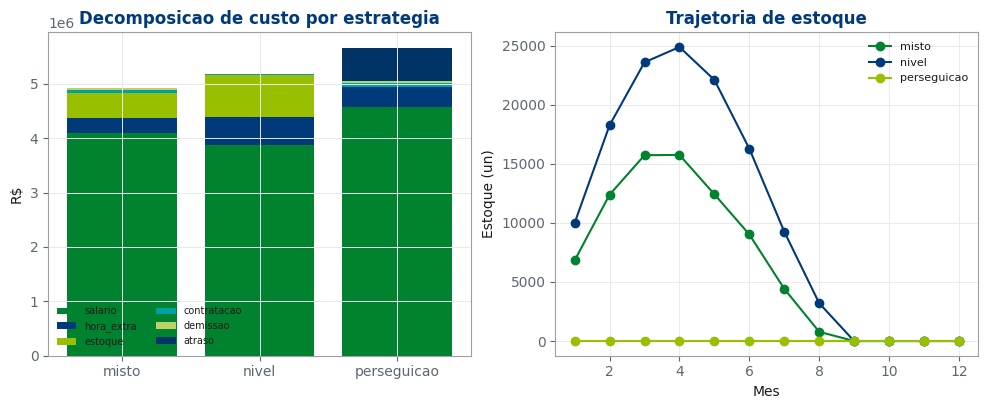

In [11]:
cats = ['salario', 'hora_extra', 'estoque', 'contratacao', 'demissao', 'atraso']
x = list(estr.keys())
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
bottom = np.zeros(len(x))
for cat in cats:
    vals = np.array([estr[m].custo[cat] for m in x])
    a1.bar(x, vals, bottom=bottom, label=cat)
    bottom += vals
a1.set(ylabel='R$', title='Decomposicao de custo por estrategia')
a1.legend(fontsize=7, ncol=2)
for m, r in estr.items():
    a2.plot(meses, r.plano['I'], marker='o', label=m)
a2.set(xlabel='Mes', ylabel='Estoque (un)', title='Trajetoria de estoque')
a2.legend(fontsize=8)
plt.show()

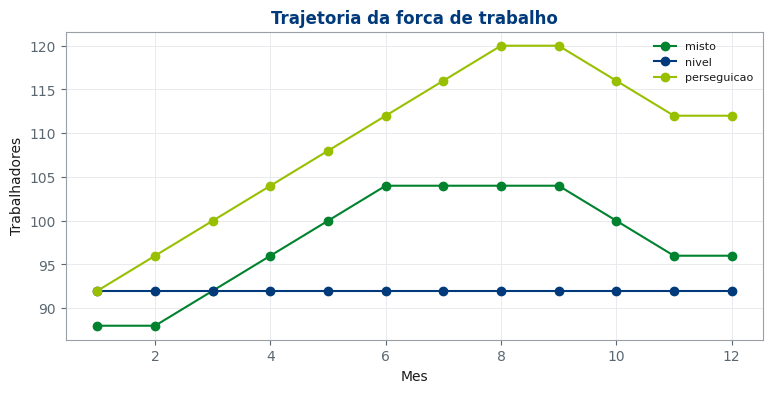

In [12]:
fig, ax = plt.subplots()
for m, r in estr.items():
    ax.plot(meses, r.plano['W'], marker='o', label=m)
ax.set(xlabel='Mes', ylabel='Trabalhadores', title='Trajetoria da forca de trabalho')
ax.legend(fontsize=8)
plt.show()

**Leitura dos cenarios:** as duas estrategias puras falham por motivos opostos.
A de nivel mantem a forca de trabalho estavel, mas paga esse conforto acumulando
estoque caro na baixa estacao. A de perseguicao evita estoque, mas os limites de ajuste
de mao de obra a impedem de acompanhar o pico, gerando contratacao/demissao e atraso. O
plano misto extrai o melhor de cada instrumento e domina ambas.

## 5. Sensibilidade e incerteza (nucleo do criterio C4)

### 5.1 Precos-sombra: quanto vale relaxar a capacidade

O preco-sombra da restricao de capacidade regular indica a economia por 1 unidade
extra de capacidade em cada mes (equivale a ~1/180 de um trabalhador). Ele so e
diferente de zero quando a capacidade esta ativa (meses de aperto rumo ao pico).

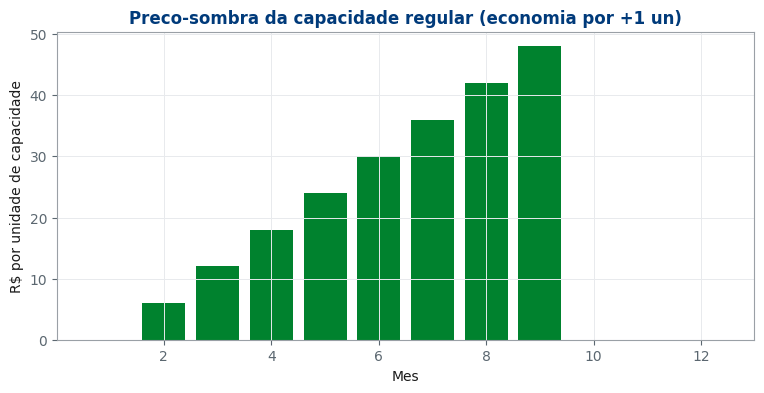

Leitura: capacidade so tem valor nos meses de aperto (pre-pico); o valor
cresce ~R$ 6/mes (custo de estoque) porque a unidade extra seria antecipada
e mantida ate o pico. Fora da janela de aperto, capacidade ociosa nao vale nada.


In [13]:
dcap = res.duais['capacidade']
valor_cap = [(-dcap[t] if dcap[t] is not None else 0.0) for t in meses]
fig, ax = plt.subplots()
ax.bar(meses, valor_cap, color=C_DESTAQUE)
ax.set(xlabel='Mes', ylabel='R$ por unidade de capacidade',
       title='Preco-sombra da capacidade regular (economia por +1 un)')
plt.show()
print('Leitura: capacidade so tem valor nos meses de aperto (pre-pico); o valor')
print('cresce ~R$ 6/mes (custo de estoque) porque a unidade extra seria antecipada')
print('e mantida ate o pico. Fora da janela de aperto, capacidade ociosa nao vale nada.')

### 5.2 Sensibilidade dos parametros (tornado)

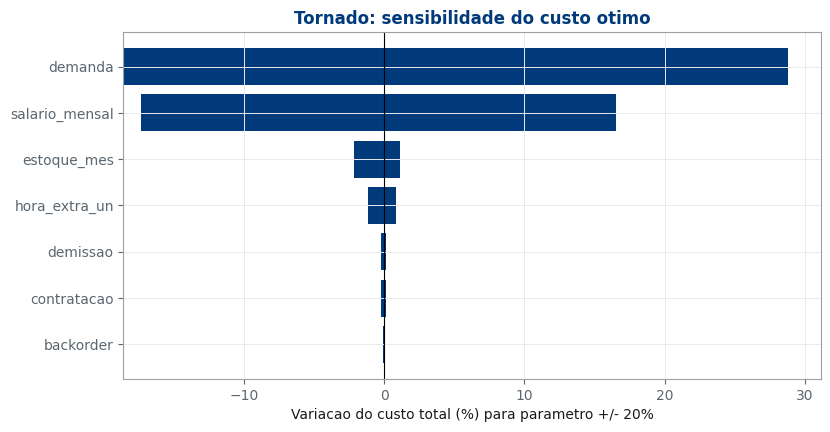

In [14]:
base_cost = res.custo_total
delta = 0.20

def custo_com_custo(param, fator):
    return resolve_pap(D_esp, 'misto', custos={param: CUSTOS[param] * fator}).custo_total

linhas = []
for p in ['salario_mensal', 'hora_extra_un', 'estoque_mes',
          'contratacao', 'demissao', 'backorder']:
    lo = (custo_com_custo(p, 1 - delta) / base_cost - 1) * 100
    hi = (custo_com_custo(p, 1 + delta) / base_cost - 1) * 100
    linhas.append((p, lo, hi))
# demanda +/- 20%
lo_d = (resolve_pap(D_esp * (1 - delta), 'misto').custo_total / base_cost - 1) * 100
hi_d = (resolve_pap(D_esp * (1 + delta), 'misto').custo_total / base_cost - 1) * 100
linhas.append(('demanda', lo_d, hi_d))

linhas.sort(key=lambda r: abs(r[2] - r[1]))
nomes = [r[0] for r in linhas]
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, (nome, lo, hi) in enumerate(linhas):
    ax.barh(i, hi - lo, left=min(lo, hi), color=C_REGULAR)
ax.set_yticks(range(len(nomes)))
ax.set_yticklabels(nomes)
ax.axvline(0, color='k', lw=0.8)
ax.set(xlabel='Variacao do custo total (%) para parametro +/- 20%',
       title='Tornado: sensibilidade do custo otimo')
plt.show()

### 5.3 Fronteira custo x nivel de servico

Elevar o nivel de servico exige mais estoque de seguranca (SS_t = z * CV_erro * D_t),
que custa mais. A fronteira mostra o preco de cada ponto adicional de servico e usa
diretamente o erro de previsao medido na Fase 2.

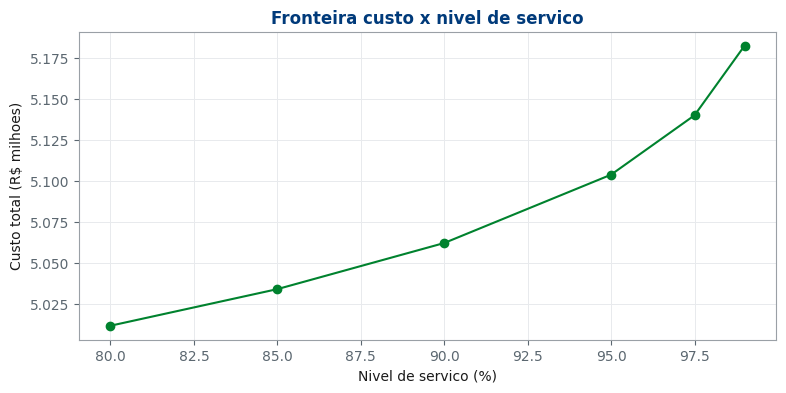

,nivel_servico_%,custo_total,acrescimo_vs_80
0,80.0,5011742.42,0.00
1,85.0,5034058.22,0.45
2,90.0,5062164.29,1.01
3,95.0,5103825.05,1.84
4,97.5,5140022.01,2.56
5,99.0,5182438.15,3.41


In [15]:
niveis = [0.80, 0.85, 0.90, 0.95, 0.975, 0.99]
front = []
for sl in niveis:
    ss = norm.ppf(sl) * cv_erro * D_esp
    r = resolve_pap(D_esp, 'misto', estoque_seguranca=ss)
    front.append((sl * 100, r.custo_total))
front = pd.DataFrame(front, columns=['nivel_servico_%', 'custo_total'])

fig, ax = plt.subplots()
ax.plot(front['nivel_servico_%'], front['custo_total'] / 1e6, 'o-', color=C_DESTAQUE)
ax.set(xlabel='Nivel de servico (%)', ylabel='Custo total (R$ milhoes)',
       title='Fronteira custo x nivel de servico')
plt.show()
front.assign(acrescimo_vs_80=lambda d: (d['custo_total'] / d['custo_total'].iloc[0] - 1) * 100).round(2)

### 5.4 Monte Carlo: o plano comprometido sob incerteza

Fixamos a producao do plano (decisao comprometida) e simulamos 2000 realizacoes da
demanda (forecast +/- erro). Comparamos o plano SEM estoque de seguranca com o plano
COM SS de 95%: o SS custa mais, mas eleva o nivel de servico realizado.

In [16]:
def simula(plan, N=2000):
    prod_tot = np.array(plan.plano['P']) + np.array(plan.plano['O'])
    fixo = (plan.custo['salario'] + plan.custo['hora_extra']
            + plan.custo['contratacao'] + plan.custo['demissao'])
    cI, cB = CUSTOS['estoque_mes'], CUSTOS['backorder']
    I0 = CAPACIDADE['estoque_inicial']
    rng = get_rng()
    tot = np.empty(N); fill = np.empty(N)
    for i in range(N):
        d = D_esp * (1 + rng.normal(0, cv_erro, size=len(D_esp)))
        inv = I0; hold = 0.0; falta = 0.0; unmet = 0.0
        for t in range(len(d)):
            inv = inv + prod_tot[t] - d[t]
            if inv >= 0:
                hold += inv
            else:
                unmet += -inv; falta += -inv; inv = 0.0
        tot[i] = fixo + cI * hold + cB * falta
        fill[i] = 1 - unmet / d.sum()
    return tot, fill

plano_base = resolve_pap(D_esp, 'misto')
ss95 = norm.ppf(NIVEL_SERVICO_ALVO) * cv_erro * D_esp
plano_ss = resolve_pap(D_esp, 'misto', estoque_seguranca=ss95)

c_base, f_base = simula(plano_base)
c_ss, f_ss = simula(plano_ss)
print(f'SEM estoque de seguranca : custo medio R$ {c_base.mean():,.0f} | '
      f'nivel de servico medio {f_base.mean():.1%} | servico >=95% em {(f_base>=0.95).mean():.0%} dos cenarios')
print(f'COM estoque de seguranca : custo medio R$ {c_ss.mean():,.0f} | '
      f'nivel de servico medio {f_ss.mean():.1%} | servico >=95% em {(f_ss>=0.95).mean():.0%} dos cenarios')

SEM estoque de seguranca : custo medio R$ 5,109,744 | nivel de servico medio 98.8% | servico >=95% em 97% dos cenarios
COM estoque de seguranca : custo medio R$ 5,215,101 | nivel de servico medio 99.2% | servico >=95% em 99% dos cenarios


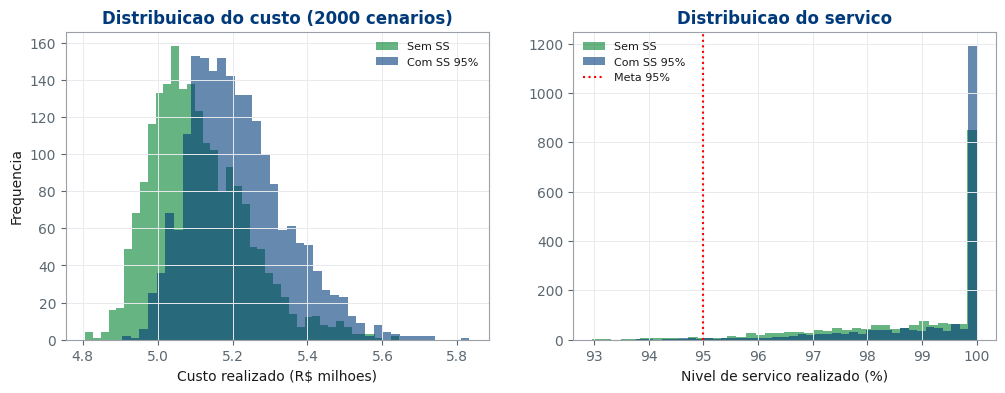

In [17]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(c_base / 1e6, bins=40, alpha=0.6, label='Sem SS')
a1.hist(c_ss / 1e6, bins=40, alpha=0.6, label='Com SS 95%')
a1.set(xlabel='Custo realizado (R$ milhoes)', ylabel='Frequencia',
       title='Distribuicao do custo (2000 cenarios)')
a1.legend(fontsize=8)
a2.hist(f_base * 100, bins=40, alpha=0.6, label='Sem SS')
a2.hist(f_ss * 100, bins=40, alpha=0.6, label='Com SS 95%')
a2.axvline(95, color='r', ls=':', label='Meta 95%')
a2.set(xlabel='Nivel de servico realizado (%)', title='Distribuicao do servico')
a2.legend(fontsize=8)
plt.show()

**Leitura do Monte Carlo:** o plano deterministico ja e razoavelmente robusto,
mas o estoque de seguranca compra protecao de cauda: eleva a fracao de cenarios que
cumprem a meta de servico, a um custo marginal pequeno. E o elo que liga o erro de
previsao (Fase 2) a decisao de estoque e nivel de servico (Fase 5).

## 6. Decisao e recomendacao

Sintese quantitativa que fecha o projeto com uma decisao explicita.

In [18]:
comp = {m: estr[m].custo_total for m in ('misto', 'nivel', 'perseguicao')}
base = comp['misto']
g_niv = (comp['nivel'] / base - 1) * 100
g_per = (comp['perseguicao'] / base - 1) * 100
custo_ss = plano_ss.custo_total
print('=== RECOMENDACAO ===')
print(f'Adotar o PLANO MISTO com estoque de seguranca de {NIVEL_SERVICO_ALVO:.0%}.')
print(f'  - Plano misto (deterministico): R$ {base:,.0f}.')
print(f'  - Domina as estrategias puras: nivel custa {g_niv:+.1f}% (estoque em excesso), '
      f'perseguicao {g_per:+.1f}% (churn + atraso).')
print(f'  - Com SS de {NIVEL_SERVICO_ALVO:.0%}: R$ {custo_ss:,.0f} '
      f'(+{(custo_ss/base-1)*100:.1f}%), elevando o servico medio realizado de '
      f'{f_base.mean():.0%} para {f_ss.mean():.0%} sob incerteza.')
print(f'  - Capacidade e o gargalo nos meses pre-pico; antecipar producao em estoque')
print(f'    e mais barato que hora extra/contratacao, por isso o plano pre-constroi.')
print('  - Risco/limitacao: custos determinísticos e um produto agregado; extensoes')
print('    naturais sao lead time estocastico e multiplos produtos (MPS/MRP).')

=== RECOMENDACAO ===
Adotar o PLANO MISTO com estoque de seguranca de 95%.
  - Plano misto (deterministico): R$ 4,915,334.
  - Domina as estrategias puras: nivel custa +5.2% (estoque em excesso), perseguicao +15.2% (churn + atraso).
  - Com SS de 95%: R$ 5,103,825 (+3.8%), elevando o servico medio realizado de 99% para 99% sob incerteza.
  - Capacidade e o gargalo nos meses pre-pico; antecipar producao em estoque
    e mais barato que hora extra/contratacao, por isso o plano pre-constroi.
  - Risco/limitacao: custos determinísticos e um produto agregado; extensoes
    naturais sao lead time estocastico e multiplos produtos (MPS/MRP).
